In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv('course_lead_scoring.csv')

In [3]:
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [4]:
 print(df.dtypes)

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object


In [5]:
columns_with_nan = df.columns[df.isna().any()].tolist()

print("Columns with NaN values:", columns_with_nan)

Columns with NaN values: ['lead_source', 'industry', 'annual_income', 'employment_status', 'location']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [7]:
# Select only the columns with 'category' dtype
categorical_columns_df = df.select_dtypes(include=['object'])

# Get the list of column names
categorical_column_names = categorical_columns_df.columns.tolist()

In [8]:
# To get a DataFrame containing only numeric columns
numeric_df = df.select_dtypes(include='number')

# To get a list of column names
numeric_column_names = df.select_dtypes(include='number').columns.tolist()

In [9]:
for col in categorical_column_names:
    fill_word = 'NA'
    #mode_value = df[col].mode()[0]  # Get the first mode if there are multiple
    df[col] = df[col].fillna(fill_word)

In [10]:
for col in numeric_column_names:
    #mode_value = df[col].mode()[0]  # Get the first mode if there are multiple
    df[col] = df[col].fillna(0.0)

In [11]:
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NA,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NA,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,0.0,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NA,5,71016.0,self_employed,north_america,0,0.25,1


In [12]:
str_cols = df.columns[df.dtypes==object]
df[str_cols] = df[str_cols].fillna('NA')
#df = df.fillna('NA)

In [13]:
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NA,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NA,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,0.0,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NA,5,71016.0,self_employed,north_america,0,0.25,1


In [14]:
# Get the mode of 'Column_A'
mode_a = df['industry'].mode()
print(f"Mode of Column_A:\n{mode_a}")

Mode of Column_A:
0    retail
Name: industry, dtype: object


### Q1 Retail


Numeric correlation matrix:


,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
number_of_courses_viewed,1.000000,0.009770,-0.023565,-0.004879,0.435914
annual_income,0.009770,1.000000,0.027036,0.015610,0.053131
interaction_count,-0.023565,0.027036,1.000000,0.009888,0.374573
lead_score,-0.004879,0.015610,0.009888,1.000000,0.193673
converted,0.435914,0.053131,0.374573,0.193673,1.000000


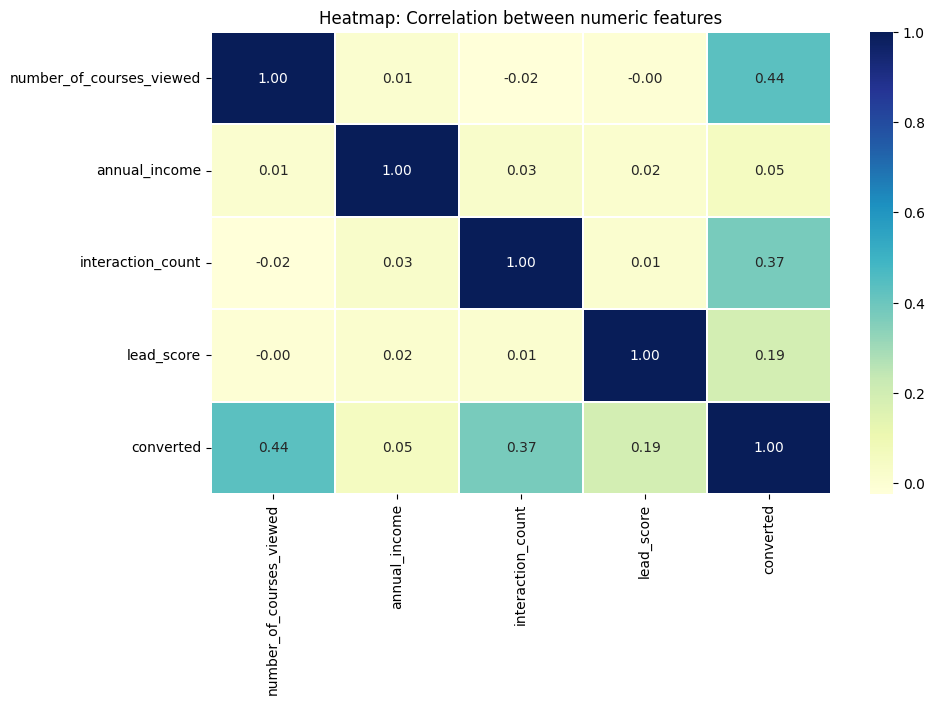

In [15]:
# Heatmap - correlation of numeric features
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] >= 2:
    corr = num_df.corr()
    print("\nNumeric correlation matrix:")
    display(corr)
    plt.figure(figsize=(10,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.3)
    plt.title("Heatmap: Correlation between numeric features")
    plt.show()
else:
    print("\nNo numeric columns (or too few) for correlation heatmap.")


---------------------------------------------------------------------------------------------------

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [18]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [19]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [20]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

-------------------------------------------------------------------------------------------------------------------------

In [21]:
categorical_column_names

['lead_source', 'industry', 'employment_status', 'location']

In [22]:
global_converted = df_full_train.converted.mean()
global_converted

np.float64(0.6073567151411463)

In [23]:
for c in categorical_column_names:
    print(c)
    df_group = df_full_train.groupby(c).converted.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_converted
    df_group['risk'] = df_group['mean'] / global_converted
    display(df_group)
    print()
    print()

lead_source


,mean,count,diff,risk
lead_source,,,,
NA,0.669725,109,0.062368,1.102688
events,0.592965,199,-0.014392,0.976304
organic_search,0.615721,229,0.008364,1.013771
paid_ads,0.428571,210,-0.178785,0.705634
referral,0.786408,206,0.179051,1.294804
social_media,0.583333,216,-0.024023,0.960446




industry


,mean,count,diff,risk
industry,,,,
NA,0.557522,113,-0.049835,0.917948
education,0.790210,143,0.182853,1.301064
finance,0.556886,167,-0.050470,0.916901
healthcare,0.593333,150,-0.014023,0.976911
manufacturing,0.621429,140,0.014072,1.023169
other,0.612903,155,0.005547,1.009132
retail,0.566265,166,-0.041092,0.932343
technology,0.562963,135,-0.044394,0.926907




employment_status


,mean,count,diff,risk
employment_status,,,,
NA,0.571429,84,-0.035928,0.940845
employed,0.671937,253,0.064580,1.106330
self_employed,0.635739,291,0.028382,1.046731
student,0.659722,288,0.052366,1.086219
unemployed,0.462451,253,-0.144906,0.761415




location


,mean,count,diff,risk
location,,,,
NA,0.680000,50,0.072643,1.119606
africa,0.592857,140,-0.014500,0.976127
asia,0.588608,158,-0.018749,0.969130
australia,0.612903,155,0.005547,1.009132
europe,0.641176,170,0.033820,1.055684
middle_east,0.644172,163,0.036815,1.060615
north_america,0.589888,178,-0.017469,0.971238
south_america,0.554839,155,-0.052518,0.913530


-----------------------------------------------------------------------

In [24]:
from sklearn.metrics import mutual_info_score

In [25]:
mutual_info_score(df_full_train.converted, df_full_train.industry)

0.011684562750165564

In [26]:
mutual_info_score(df_full_train.converted, df_full_train.location)

0.0022530354195563346

In [27]:
mutual_info_score(df_full_train.converted, df_full_train.lead_source)

0.025665373935054955

In [28]:
mutual_info_score(df_full_train.converted, df_full_train.employment_status)

0.013258496589914293

### Q3 LEAD SOURCE

**********************************************************************************

### Q4

In [29]:
df_train

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,paid_ads,retail,0,58472.0,student,middle_east,5,0.03
1,organic_search,manufacturing,3,71738.0,student,middle_east,6,0.77
2,paid_ads,technology,3,81973.0,employed,north_america,2,0.59
3,NA,technology,1,74956.0,employed,europe,3,0.34
4,organic_search,retail,3,59335.0,student,australia,1,0.98
...,...,...,...,...,...,...,...,...
871,organic_search,other,1,43907.0,employed,australia,4,0.33
872,social_media,retail,3,64969.0,employed,north_america,1,0.18
873,NA,education,3,89042.0,employed,asia,4,0.75
874,social_media,manufacturing,1,0.0,self_employed,europe,1,0.65


In [30]:
from sklearn.feature_extraction import DictVectorizer

In [31]:
categorical = categorical_column_names 

In [32]:
numerical = numeric_column_names
numerical.remove("converted")

In [33]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

---------------------------------------------------------------------------------------------------------------

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
model.coef_[0].round(3)

array([-0.   , -0.015,  0.034,  0.003,  0.012, -0.103, -0.025,  0.049,
       -0.02 , -0.013, -0.003, -0.009, -0.032, -0.016,  0.311,  0.051,
        0.02 , -0.012, -0.012, -0.115,  0.08 , -0.03 ,  0.004, -0.011,
       -0.011, -0.006,  0.008,  0.006, -0.033, -0.025,  0.454])

In [37]:
y_pred = model.predict_proba(X_val)[:, 1]

In [38]:
y_pred.mean()

np.float64(0.6587082147463391)

-------------------------------------------------------------------------------------------------------------------------

#### Q5

In [39]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))


{'annual_income': np.float64(-0.0),
 'employment_status=NA': np.float64(-0.015),
 'employment_status=employed': np.float64(0.034),
 'employment_status=self_employed': np.float64(0.003),
 'employment_status=student': np.float64(0.012),
 'employment_status=unemployed': np.float64(-0.103),
 'industry=NA': np.float64(-0.025),
 'industry=education': np.float64(0.049),
 'industry=finance': np.float64(-0.02),
 'industry=healthcare': np.float64(-0.013),
 'industry=manufacturing': np.float64(-0.003),
 'industry=other': np.float64(-0.009),
 'industry=retail': np.float64(-0.032),
 'industry=technology': np.float64(-0.016),
 'interaction_count': np.float64(0.311),
 'lead_score': np.float64(0.051),
 'lead_source=NA': np.float64(0.02),
 'lead_source=events': np.float64(-0.012),
 'lead_source=organic_search': np.float64(-0.012),
 'lead_source=paid_ads': np.float64(-0.115),
 'lead_source=referral': np.float64(0.08),
 'lead_source=social_media': np.float64(-0.03),
 'location=NA': np.float64(0.004),
 'l

#### Q6

In [41]:
from sklearn.model_selection import GridSearchCV
LRparam_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    #'penalty': ['l1', 'l2'],
    ## 'max_iter': list(range(100,800,100)),
    #'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}
LR_search = GridSearchCV(model, param_grid=LRparam_grid, refit = True, verbose = 3, cv=5)

# fitting the model for grid search 
LR_search.fit(X_train , y_train)
LR_search.best_params_
# summarize
print('Mean Accuracy: %.3f' % LR_search.best_score_)
print('Config: %s' % LR_search.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END ...........................C=0.001;, score=0.625 total time=   0.0s
[CV 2/5] END ...........................C=0.001;, score=0.629 total time=   0.0s
[CV 3/5] END ...........................C=0.001;, score=0.640 total time=   0.0s
[CV 4/5] END ...........................C=0.001;, score=0.634 total time=   0.0s
[CV 5/5] END ...........................C=0.001;, score=0.634 total time=   0.0s
[CV 1/5] END ............................C=0.01;, score=0.756 total time=   0.0s
[CV 2/5] END ............................C=0.01;, score=0.760 total time=   0.0s
[CV 3/5] END ............................C=0.01;, score=0.737 total time=   0.0s
[CV 4/5] END ............................C=0.01;, score=0.737 total time=   0.0s
[CV 5/5] END ............................C=0.01;, score=0.720 total time=   0.0s
[CV 1/5] END .............................C=0.1;, score=0.744 total time=   0.0s
[CV 2/5] END .............................C=0.1;,

In [ ]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

In [44]:
from sklearn.metrics import accuracy_score

In [46]:
# https://www.kaggle.com/code/joparga3/2-tuning-parameters-for-logistic-regression#Testing-different-parameters-to-understand-how-accuracies-change.
C_param_range = [0.001,0.01,0.1,1,10,100]

acc_table = pd.DataFrame(columns = ['C_parameter','Accuracy'])
acc_table['C_parameter'] = C_param_range

#plt.figure(figsize=(10, 10))

j = 0
for i in C_param_range:
    
    # Apply logistic regression model to training data
    model = LogisticRegression(solver='liblinear', C=i, max_iter=1000, random_state=42)
    model.fit(X_train,y_train)
    
    # Predict using model
    y_pred = model.predict(X_val)
    
    # Saving accuracy score in table
    acc_table.iloc[j,1] = accuracy_score(y_test,y_pred)
    j += 1
    
    # Printing decision regions
    #plt.subplot(3,2,j)
    #plt.subplots_adjust(hspace = 0.4)
    #plot_decision_regions(X = X_combined_sepal_standard
    #                  , y = Y_combined_sepal
    #                  , classifier = lr
    #                  , test_idx = range(105,150))
    #plt.xlabel('Sepal length')
    #plt.ylabel('Sepal width')
    #plt.title('C = %s'%i)

In [47]:
acc_table

,C_parameter,Accuracy
0,0.001,0.658703
1,0.010,0.638225
2,0.100,0.638225
3,1.000,0.638225
4,10.000,0.638225
5,100.000,0.638225


### ANSWER 6. 0.001